# **Car Price Prediction with Machine Learning**

### 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load Dataset

In [3]:
df = pd.read_csv("car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


# Dataset Overview

The dataset contains information about different cars, including their selling price, present price, fuel type, transmission type, ownership details, and age. The objective is to build a machine learning model that can predict the selling price of a car.

### 3. Dataset Information

In [4]:
df.shape

(301, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


# Observation:

The dataset was inspected to understand the number of records, data types, and missing values. This step helps ensure that the dataset is suitable for machine learning.

### 4. Exploratory Data Analysis (EDA)

     Selling Price Distribution

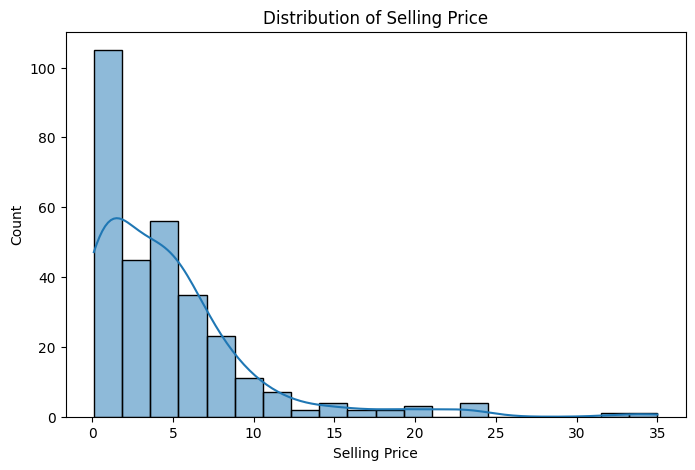

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['Selling_Price'], bins=20, kde=True)

plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Count')

plt.show()

### Observation:

Most cars are concentrated in the lower selling price range, while only a few cars have very high selling prices.

# Correlation Heatmap

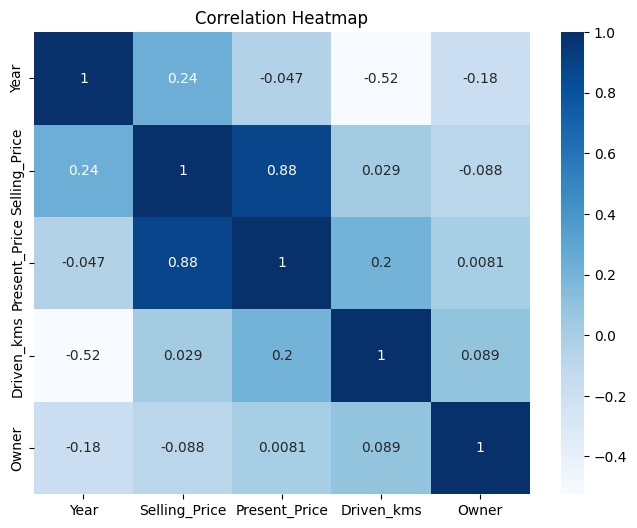

In [8]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues')

plt.title('Correlation Heatmap')
plt.show()

### Observation:

The heatmap helps identify relationships between numerical variables. Strong correlations indicate variables that may significantly influence car prices.

### 5. Feature Engineering

In [9]:
df['Car_Age'] = 2026 - df['Year']

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


### Observation:

A new feature called Car_Age was created from the Year column. Older cars generally have lower resale values compared to newer cars.

### 6. Data Preprocessing for Machine Learning

In [10]:
df = df.drop(['Car_Name'], axis=1)

df = pd.get_dummies(
    df,
    columns=['Fuel_Type', 'Selling_type', 'Transmission'],
    drop_first=True
)

df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,12,False,True,False,True
1,2013,4.75,9.54,43000,0,13,True,False,False,True
2,2017,7.25,9.85,6900,0,9,False,True,False,True
3,2011,2.85,4.15,5200,0,15,False,True,False,True
4,2014,4.60,6.87,42450,0,12,True,False,False,True


### Observation:

Categorical variables were converted into numerical form using one-hot encoding. This step is necessary because machine learning models require numerical input data.

### 7. Train-Test Split

In [11]:
X = df.drop(['Selling_Price'], axis=1)
y = df['Selling_Price']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(240, 9)
(61, 9)


### Observation:

The dataset was divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate performance.

### 8. Model Training

In [12]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Observation:

A Random Forest Regressor was used to learn the relationship between car features and selling price.

### 9. Model Evaluation

In [13]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9624761729725145
MAE: 0.6197819672131152


### Observation:

The model achieved an R² score of 0.96, indicating excellent predictive performance. The low MAE value shows that the model's predictions are very close to the actual car prices.

### 10. Actual vs Predicted Price Graph

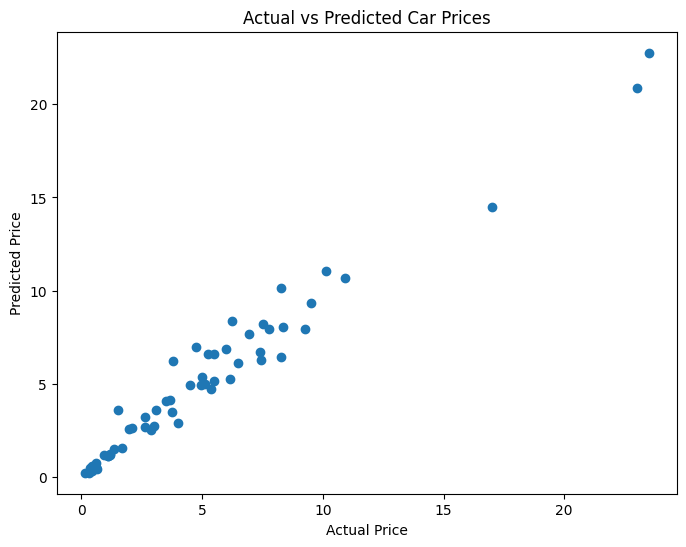

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

### Observation:

The scatter plot compares actual car prices with predicted car prices. Most points are close to the ideal trend, indicating that the model performs well in predicting car prices.

# Conclusion

In this project, a Random Forest Regressor was used to predict car selling prices based on various car features. Data preprocessing, exploratory data analysis, feature engineering, and model evaluation were performed. The model achieved an R² score of 0.96, indicating excellent predictive performance. This project demonstrates the effectiveness of machine learning techniques in car price prediction.